# Neutral Pose Visualization
This notebook visualizes what the "neutral" starting position looks like for the rodent model.

In [1]:
import os
os.environ["MUJOCO_GL"] = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"

import jax
import jax.numpy as jnp
import mujoco
from mujoco import mjx
import numpy as np
import mediapy as media
from ml_collections import config_dict

from vnl_playground.tasks.rodent import imitation
from vnl_playground.tasks.rodent import wrappers as vnl_wrappers
from vnl_playground.tasks.rodent.reference_clips import ReferenceClips

In [2]:
# Create the environment config
env_cfg = imitation.default_config()
env_cfg.clip_length = 250

# Load reference clips (needed for environment initialization)
reference_clips = ReferenceClips(
    data_path=env_cfg.reference_data_path,
    n_frames_per_clip=env_cfg.clip_length,
)

# Create the environment
env = imitation.Imitation(config=env_cfg, clips=reference_clips)
print(f"Model nq (qpos size): {env.mj_model.nq}")
print(f"Model nv (qvel size): {env.mj_model.nv}")

Model nq (qpos size): 74
Model nv (qvel size): 73


In [3]:
# Get the neutral/default qpos from the model
# This is the pose defined in the XML file (qpos0)
neutral_qpos = env.mj_model.qpos0.copy()
print(f"Neutral qpos shape: {neutral_qpos.shape}")
print(f"Neutral qpos (first 10 values): {neutral_qpos[:10]}")
print(f"\nRoot position (x, y, z): {neutral_qpos[:3]}")
print(f"Root quaternion (w, x, y, z): {neutral_qpos[3:7]}")

Neutral qpos shape: (74,)
Neutral qpos (first 10 values): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]

Root position (x, y, z): [0. 0. 0.]
Root quaternion (w, x, y, z): [1. 0. 0. 0.]


In [4]:
# Create MuJoCo data with neutral pose and render it
mj_data = mujoco.MjData(env.mj_model)
mj_data.qpos[:] = neutral_qpos
mujoco.mj_forward(env.mj_model, mj_data)

# Render from multiple camera angles
renderer = mujoco.Renderer(env.mj_model, height=480, width=640)

# Get available cameras
camera_names = [env.mj_model.camera(i).name for i in range(env.mj_model.ncam)]
print(f"Available cameras: {camera_names}")

Available cameras: ['close_profile-rodent', 'back-rodent', 'side-rodent', 'side_alt-rodent', 'top-rodent', 'egocentric-rodent']


Neutral Pose - Side View

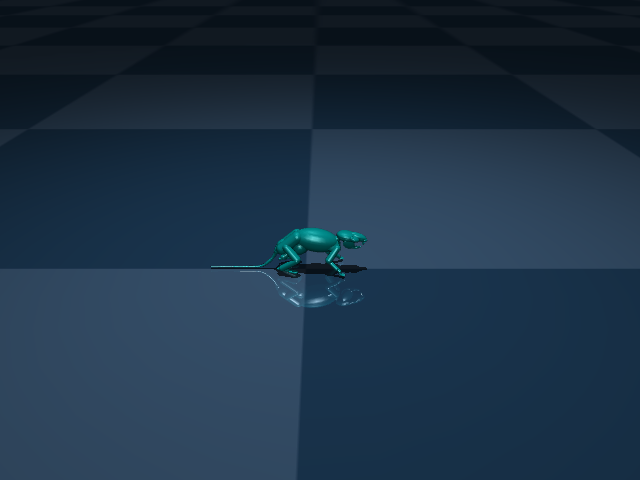

In [5]:
# Render neutral pose from side view
renderer.update_scene(mj_data, camera="side-rodent")
neutral_frame_side = renderer.render()
media.show_image(neutral_frame_side, title="Neutral Pose - Side View")

In [ ]:
# Render neutral pose from top view
renderer.update_scene(mj_data, camera="top-rodent")
neutral_frame_top = renderer.render()
media.show_image(neutral_frame_top, title="Neutral Pose - Top View")

Reference qpos (first 10 values): [-0.07436896 -0.09192777  0.01181851  0.98876625  0.09398538  0.0083713
  0.11592306 -0.40345904 -0.27155212  0.04324755]

Reference root position (x, y, z): [-0.07436896 -0.09192777  0.01181851]
Reference root quaternion (w, x, y, z): [0.98876625 0.09398538 0.0083713  0.11592306]


"Reference Clip 0, Frame 0 - Side View"

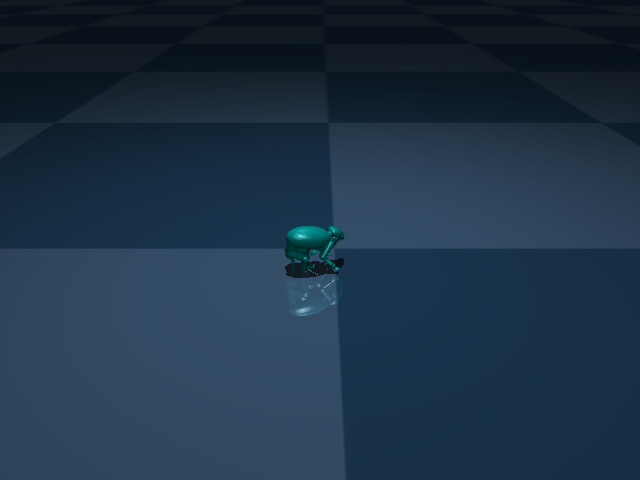

In [6]:
# Compare with a reference clip pose
# Get a frame from reference clip 0
ref_qpos = reference_clips.at(clip=4, frame=0).qpos
print(f"Reference qpos (first 10 values): {ref_qpos[:10]}")
print(f"\nReference root position (x, y, z): {ref_qpos[:3]}")
print(f"Reference root quaternion (w, x, y, z): {ref_qpos[3:7]}")

# Render reference pose
mj_data.qpos[:] = np.array(ref_qpos)
mujoco.mj_forward(env.mj_model, mj_data)
renderer.update_scene(mj_data, camera="side-rodent")
ref_frame = renderer.render()
media.show_image(ref_frame, title="Reference Clip 0, Frame 0 - Side View")

In [7]:
mj_data.qvel

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.])

In [21]:
mj_data

In [ ]:
# Show neutral pose with noise added
# This demonstrates what sampling with variance would look like

noise_stds = [0.0, 0.01, 0.05, 0.1]
frames = []

for noise_std in noise_stds:
    noisy_qpos = neutral_qpos.copy()
    if noise_std > 0:
        # Add noise only to joint angles (not root position/quaternion)
        # Root is indices 0-6 (3 pos + 4 quat), joints are 7 onwards
        joint_noise = np.random.normal(0, noise_std, size=neutral_qpos.shape[0] - 7)
        noisy_qpos[7:] += joint_noise
    
    mj_data.qpos[:] = noisy_qpos
    mujoco.mj_forward(env.mj_model, mj_data)
    renderer.update_scene(mj_data, camera="side-rodent")
    frame = renderer.render()
    frames.append(frame)

# Display side by side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (ax, frame, std) in enumerate(zip(axes, frames, noise_stds)):
    ax.imshow(frame)
    ax.set_title(f"noise_std = {std}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Check torso height in neutral pose
mj_data.qpos[:] = neutral_qpos
mujoco.mj_forward(env.mj_model, mj_data)

# The torso z is typically at qpos[2] for a free joint
print(f"Neutral torso z position: {neutral_qpos[2]}")
print(f"Healthy z range from config: {env_cfg.reward_terms['torso_z_range']['healthy_z_range']}")